# NLB `mc_maze` results walkthrough

**What this notebook is:** a 90-second skim of the repo's portfolio comparison, generated from the tracked `metrics.csv` files under `results/benchmark_runs/`. No model training happens here — this is a reading of the saved numbers.

**What's being compared:** six lightweight models on the NLB'21 `mc_maze` train/val split, all under the `log_link` rate readout. Two axes:
- **`co-bps`** — co-smoothing bits-per-spike, the primary NLB metric (higher is better; positive means better than a trivial predictor).
- **`vel R2`** — decoded hand-velocity R² from the predicted held-out rates, a behavioural secondary check.

**Headline takeaway:**
- Adding short neural history (the "lagged" family) is the single move that separates competitive models from static baselines. Every lagged row beats every static row on `co-bps`.
- On `co-bps` alone, supervised low-rank regression (RRR) ties with unsupervised PCA compression once history is included. The useful discriminator is `vel R2`, where the PCA bottleneck captures more behaviour-aligned structure.

## 1. Load every tracked benchmark run

Each subdirectory under `results/benchmark_runs/` is one model family's saved results. We pick the best row per run by validation `co-bps` and collect them into a single comparison table.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Markdown

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RUNS_DIR = REPO_ROOT / "results" / "benchmark_runs"
assert RUNS_DIR.is_dir(), f"Could not find {RUNS_DIR}"

run_frames = []
for metrics_path in sorted(RUNS_DIR.glob("*/metrics.csv")):
    df = pd.read_csv(metrics_path)
    df.insert(0, "run", metrics_path.parent.name)
    run_frames.append(df)

raw_runs = pd.concat(run_frames, ignore_index=True)
print(f"Loaded {len(raw_runs)} rows from {raw_runs['run'].nunique()} runs.")

Markdown(
    raw_runs[["run", "model", "model_type", "co-bps", "vel R2"]].round(4).to_markdown(index=False)
)

Loaded 14 rows from 7 runs.


| run                      | model    | model_type                     |   co-bps |   vel R2 |
|:-------------------------|:---------|:-------------------------------|---------:|---------:|
| lagged_pca_history_sweep | baseline | lagged_pca_latent_regression   |   0.0166 |   0.24   |
| lagged_pca_history_sweep | improved | lagged_pca_latent_regression   |   0.0266 |   0.3648 |
| lagged_pca_single        | baseline | lagged_pca_latent_regression   |   0.0166 |   0.24   |
| lagged_pca_single        | improved | lagged_pca_latent_regression   |   0.0166 |   0.24   |
| lagged_ridge_single      | baseline | lagged_ridge_direct            |   0.0215 |   0.1986 |
| lagged_ridge_single      | improved | lagged_ridge_direct            |   0.0215 |   0.1986 |
| lagged_rrr_sweep         | baseline | lagged_reduced_rank_regression |   0.0177 |   0.1809 |
| lagged_rrr_sweep         | improved | lagged_reduced_rank_regression |   0.0283 |   0.2316 |
| lds_pca_sweep            | baseline | lds_pca_latent_regression      |  -0.0033 |   0.0759 |
| lds_pca_sweep            | improved | lds_pca_latent_regression      |  -0.0028 |   0.0754 |
| static_pca               | baseline | pca_latent_regression          |  -0.0068 |   0.0756 |
| static_pca               | improved | pca_latent_regression          |  -0.0068 |   0.0756 |
| static_ridge             | baseline | ridge_direct                   |   0.0017 |   0.0769 |
| static_ridge             | improved | ridge_direct                   |   0.0017 |   0.0769 |

## 2. Reconstruct the portfolio comparison table

We reuse `nlb_project.reporting.build_comparison_rows` — the same code the CI pipeline runs — so this table is guaranteed to match the committed `results/benchmark_runs/model_comparison.csv`. Each row is the "selected" or baseline configuration for one model family.

In [2]:
import sys

sys.path.insert(0, str(REPO_ROOT / "src"))

from nlb_project.reporting import build_comparison_rows  # noqa: E402

rows = build_comparison_rows(REPO_ROOT)
comparison = pd.DataFrame(rows)

display_cols = [
    "model_label",
    "role",
    "history_bins",
    "n_components",
    "rank",
    "ridge_alpha",
    "input_transform",
    "co_bps",
    "vel_r2",
]

Markdown(comparison[display_cols].round(4).to_markdown(index=False))

| model_label                                     | role      |   history_bins |   n_components |   rank |   ridge_alpha | input_transform   |   co_bps |   vel_r2 |
|:------------------------------------------------|:----------|---------------:|---------------:|-------:|--------------:|:------------------|---------:|---------:|
| static PCA latent regression                    | reference |                |             10 |        |           0.1 | none              |  -0.0068 |   0.0756 |
| static direct ridge                             | reference |                |                |        |           0.1 | none              |   0.0017 |   0.0769 |
| lagged direct ridge (5 bins)                    | reference |              5 |                |        |           0.1 | sqrt              |   0.0215 |   0.1986 |
| lagged reduced-rank regression (selected)       | selected  |              9 |                |     20 |           0.1 | sqrt_zscore       |   0.0283 |   0.2316 |
| lagged PCA latent regression (5 bins)           | reference |              5 |             20 |        |           0.1 | sqrt_zscore       |   0.0166 |   0.24   |
| lagged PCA latent regression (selected history) | selected  |              9 |             20 |        |           0.1 | sqrt_zscore       |   0.0266 |   0.3648 |

## 3. `co-bps` across models

Every lagged model beats every static model on co-bps. The best static row (static direct ridge, `0.0017`) is an order of magnitude below the worst lagged row (lagged PCA 5-bin, `0.0166`). RRR and lagged PCA (selected history) tie at the top within `~0.002`.

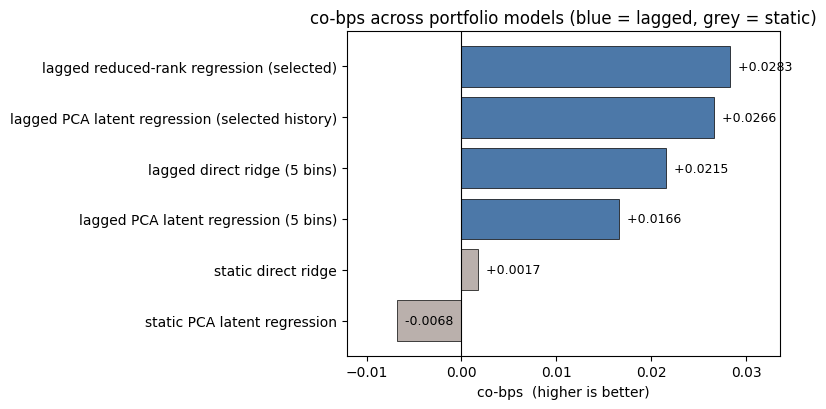

In [3]:
import matplotlib.pyplot as plt

plot_df = comparison.sort_values("co_bps").reset_index(drop=True)
is_lagged = plot_df["model_type"].str.startswith("lagged")
colors = ["#4c78a8" if lag else "#bab0ac" for lag in is_lagged]

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.barh(plot_df["model_label"], plot_df["co_bps"], color=colors, edgecolor="black", linewidth=0.5)
ax.axvline(0.0, color="black", linewidth=0.8)
ax.set_xlabel("co-bps  (higher is better)")
ax.set_title("co-bps across portfolio models (blue = lagged, grey = static)")
for y, value in enumerate(plot_df["co_bps"]):
    ax.text(value, y, f"  {value:+.4f}", va="center", fontsize=9)
ax.margins(x=0.15)
fig.tight_layout()
plt.show()

## 4. `co-bps` vs `vel R2`

`co-bps` alone does not pick a single winner among the lagged models — RRR and lagged PCA sit on top of each other. The useful discriminator is `vel R2`: lagged PCA's unsupervised bottleneck captures substantially more behaviour-aligned structure (`0.36` vs `0.23`), which is why it is reported as the headline validated model.

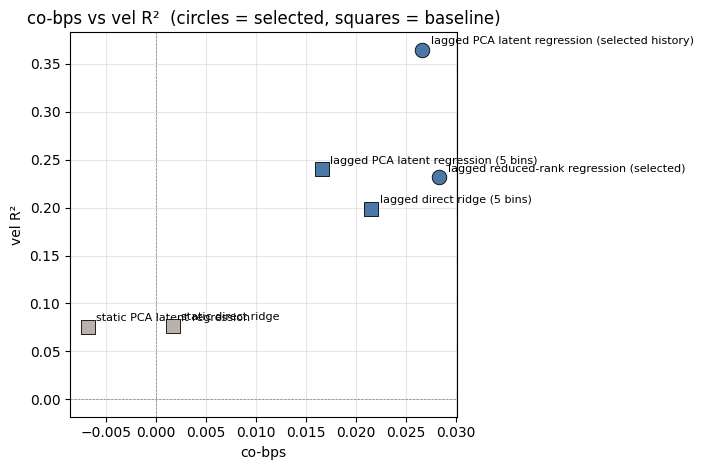

In [4]:
fig, ax = plt.subplots(figsize=(7, 4.8))
for _, row in comparison.iterrows():
    marker = "o" if row["role"] == "selected" else "s"
    color = "#4c78a8" if str(row["model_type"]).startswith("lagged") else "#bab0ac"
    ax.scatter(
        row["co_bps"],
        row["vel_r2"],
        s=110,
        marker=marker,
        color=color,
        edgecolor="black",
        linewidth=0.6,
        zorder=3,
    )
    ax.annotate(
        row["model_label"],
        (row["co_bps"], row["vel_r2"]),
        xytext=(6, 4),
        textcoords="offset points",
        fontsize=8,
    )

ax.axvline(0.0, color="gray", linewidth=0.5, linestyle="--")
ax.axhline(0.0, color="gray", linewidth=0.5, linestyle="--")
ax.set_xlabel("co-bps")
ax.set_ylabel("vel R²")
ax.set_title("co-bps vs vel R²  (circles = selected, squares = baseline)")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## 5. What actually moved the needle

1. **Temporal context** (lagged features) — the single biggest jump, from `~0` to `>0.02` co-bps.
2. **A latent bottleneck on top of lagged features** — marginal on co-bps, but decisive on `vel R²`.
3. **Supervised vs unsupervised bottleneck** — RRR and PCA are indistinguishable on co-bps; the behaviour-aligned structure comes for free from the unsupervised compression.

See [`docs/output_head_postmortem.md`](../docs/output_head_postmortem.md) for how the earlier version of this repo got the narrative wrong because of a clipped Gaussian rate readout, and [`results/benchmark_runs/`](../results/benchmark_runs/) for the raw `metrics.csv` files this notebook reads.